Ola Hassan, PhD


In [1]:
#Import packages:

import pandas as pd
import numpy as np

from pathlib import Path
import os
import glob

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,6)
sns.set_style("whitegrid")

To get and copy the path of a folder:

Method 1: Drag and Drop Open Finder. Find the folder you want. Open Terminal. Drag the folder from Finder into the Terminal window.

Method 2: Copy Pathname In Finder, right-click the folder. Hold the Option (⌥) key. You'll see "Copy 'FolderName' as Pathname"

In [3]:
#Read files:

GBM_DATA_PATH =  "/Users/olahassan/Desktop/Python/TCGA_GBM"

PROJECT = Path("/Users/olahassan/Desktop/Python/TCGA_GBM")

TUMOR_PATH = os.path.join(GBM_DATA_PATH, "Tumor")

NORMAL_PATH = os.path.join(GBM_DATA_PATH, "Normal")

OUTPUT_PATH = "/Users/olahassan/Desktop/Python/TCGA_GBM/results"


In [6]:
#Project Paths:

PROJECT = Path("/Users/olahassan/Desktop/Python/TCGA_GBM")

DATA = PROJECT / "data_processed"

RESULTS = PROJECT / "results"

FIGURES = RESULTS / "Figures"

TABLES = RESULTS / "Tables"

DESEQ = RESULTS / "DESeq2"

for folder in [FIGURES, TABLES, DESEQ]:
    folder.mkdir(parents=True, exist_ok=True)



In [8]:
#validate files exist

print(os.listdir(GBM_DATA_PATH))

['.DS_Store', 'data_processed', 'Tumor', 'results', 'Normal', 'notebooks']


In [10]:
#Load the filetered counts  produced in QC Notebook:

counts = pd.read_csv(
    DATA / "count_matrix_ensembl.csv",
    index_col=0
)

metadata = pd.read_csv(
    DATA / "metadata.csv",
    index_col=0
)

In [12]:
#Verify inputs

print(counts.shape)
print(metadata.shape)

counts.head()

metadata

(59427, 10)
(10, 1)


,condition
sample,
77c261f0-384c-4906-a57e-7c3b35c17041,Tumor
99ff2016-a97a-4142-b70a-1bb59d6264e9,Tumor
d4649bc7-09d2-4d90-bafd-0bec72429b00,Tumor
afbd1975-263b-404b-a738-886bf25c0223,Tumor
444a2332-9e52-4cf8-94d9-07a8b829633e,Tumor
64a2ddbe-3614-409a-af16-170a1471db2a,Normal
4bed9101-07f4-4d76-b79f-6eb8de04bd19,Normal
ddaed459-ab19-4f75-a1a9-72761287c6f5,Normal
477a4ae1-84c0-49f2-b3b3-4015b8c26f18,Normal


In [14]:
#Check sample order (counts.columns and metadata.index must be identical)

counts.columns

Index(['77c261f0-384c-4906-a57e-7c3b35c17041',
       '99ff2016-a97a-4142-b70a-1bb59d6264e9',
       'd4649bc7-09d2-4d90-bafd-0bec72429b00',
       'afbd1975-263b-404b-a738-886bf25c0223',
       '444a2332-9e52-4cf8-94d9-07a8b829633e',
       '64a2ddbe-3614-409a-af16-170a1471db2a',
       '4bed9101-07f4-4d76-b79f-6eb8de04bd19',
       'ddaed459-ab19-4f75-a1a9-72761287c6f5',
       '477a4ae1-84c0-49f2-b3b3-4015b8c26f18',
       'c410d37e-e445-4f5f-8937-e6796dd52364'],
      dtype='object')

In [16]:
metadata.index

Index(['77c261f0-384c-4906-a57e-7c3b35c17041',
       '99ff2016-a97a-4142-b70a-1bb59d6264e9',
       'd4649bc7-09d2-4d90-bafd-0bec72429b00',
       'afbd1975-263b-404b-a738-886bf25c0223',
       '444a2332-9e52-4cf8-94d9-07a8b829633e',
       '64a2ddbe-3614-409a-af16-170a1471db2a',
       '4bed9101-07f4-4d76-b79f-6eb8de04bd19',
       'ddaed459-ab19-4f75-a1a9-72761287c6f5',
       '477a4ae1-84c0-49f2-b3b3-4015b8c26f18',
       'c410d37e-e445-4f5f-8937-e6796dd52364'],
      dtype='object', name='sample')

In [18]:
#another way to verify 

all(counts.columns == metadata.index)

True

In [20]:
#PyDESeq2 expects
#Rows = samples
#Columns = genes
#so transpose the count matrix.



dds = DeseqDataSet(
    counts=counts.T,
    metadata=metadata,
    design="condition",
)

In [22]:
#Run DEseq


dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.03 seconds.

Fitting dispersions...
... done in 1.98 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 2.13 seconds.

Fitting LFCs...
... done in 1.73 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



In [24]:
#Differential expression

from pydeseq2.ds import DeseqStats

stat_res = DeseqStats(
    dds,
    contrast=["condition", "Tumor", "Normal"]
)

stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition Tumor vs Normal
                    baseMean  log2FoldChange     lfcSE      stat  \
gene_id                                                            
ENSG00000000003  1310.916106        1.735695  0.255598  6.790731   
ENSG00000000005     5.385968       -0.136794  0.759379 -0.180139   
ENSG00000000419  1009.118013       -0.174900  0.306689 -0.570285   
ENSG00000000457   633.084769        0.306104  0.235107  1.301976   
ENSG00000000460   255.683299        1.896872  0.366085  5.181506   
...                      ...             ...       ...       ...   
ENSG00000288669     0.096456       -0.955989  3.480652 -0.274658   
ENSG00000288670   590.816657       -1.512698  0.401993 -3.762994   
ENSG00000288671     0.000000             NaN       NaN       NaN   
ENSG00000288674     8.616878       -0.126347  0.676474 -0.186773   
ENSG00000288675    39.719476       -0.336662  0.512694 -0.656653   

                       pvalue          padj  
gene_

... done in 1.11 seconds.



In [26]:
#Extract results:

results = stat_res.results_df.copy()

results.head()



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,1310.916106,1.735695,0.255598,6.790731,1.115667e-11,1.209668e-09
ENSG00000000005,5.385968,-0.136794,0.759379,-0.180139,8.570434e-01,8.985347e-01
ENSG00000000419,1009.118013,-0.174900,0.306689,-0.570285,5.684845e-01,6.647768e-01
ENSG00000000457,633.084769,0.306104,0.235107,1.301976,1.929245e-01,2.861158e-01
ENSG00000000460,255.683299,1.896872,0.366085,5.181506,2.201017e-07,5.797922e-06


In [28]:
#read gene annotation file to merge gene Ids

gene_annotation = pd.read_csv(
    DATA / "gene_annotation_GENCODE.csv",
    index_col=0)

In [30]:
# convert ensemble IDs to gene symbols

#DESeq2 often keeps the Ensembl IDs (ENSG...), but for interpretation and figures you almost always want HGNC gene symbols (e.g., MMP11, ESR1, BRCA1).
#Since we downloaded STAR - Counts from GDC, the original count files already contained both:

results = (
    results
    .reset_index()
    .merge(
        gene_annotation,
        left_on="gene_id",
        right_on="ensembl_id",
        how="left"
    )
)

results.head()


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_symbol
0,ENSG00000000003,1310.916106,1.735695,0.255598,6.790731,1.115667e-11,1.209668e-09,TSPAN6
1,ENSG00000000005,5.385968,-0.136794,0.759379,-0.180139,8.570434e-01,8.985347e-01,TNMD
2,ENSG00000000419,1009.118013,-0.174900,0.306689,-0.570285,5.684845e-01,6.647768e-01,DPM1
3,ENSG00000000457,633.084769,0.306104,0.235107,1.301976,1.929245e-01,2.861158e-01,SCYL3
4,ENSG00000000460,255.683299,1.896872,0.366085,5.181506,2.201017e-07,5.797922e-06,C1orf112


In [32]:
#Clean your results, Keep only one gene symbol column.

results = results.set_index("gene_symbol")


In [34]:
results.head()


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_symbol,,,,,,,
TSPAN6,ENSG00000000003,1310.916106,1.735695,0.255598,6.790731,1.115667e-11,1.209668e-09
TNMD,ENSG00000000005,5.385968,-0.136794,0.759379,-0.180139,8.570434e-01,8.985347e-01
DPM1,ENSG00000000419,1009.118013,-0.174900,0.306689,-0.570285,5.684845e-01,6.647768e-01
SCYL3,ENSG00000000457,633.084769,0.306104,0.235107,1.301976,1.929245e-01,2.861158e-01
C1orf112,ENSG00000000460,255.683299,1.896872,0.366085,5.181506,2.201017e-07,5.797922e-06


In [36]:
#Save differential expression results

#results.to_csv(DESEQ / "DESeq2_results.csv")

#read results 

#results = pd.read_csv(DESEQ / "DESeq2_results.csv", index_col=0)

In [38]:
#Remove missing adjusted p-values

results = results.dropna(subset=["padj"])

In [40]:
#Add significance labels 

results["Significant"] = "Not Significant"

results.loc[
    (results["padj"] < 0.05) &
    (results["log2FoldChange"] > 1),
    "Significant"
] = "Upregulated"

results.loc[
    (results["padj"] < 0.05) &
    (results["log2FoldChange"] < -1),
    "Significant"
] = "Downregulated"

In [42]:
#Summary statistics

results["Significant"].value_counts()

Significant
Not Significant    22454
Upregulated         9644
Downregulated       4333
Name: count, dtype: int64

In [44]:
#Volcano plot


plot_data = results.copy()

plot_data["minus_log10_padj"] = -np.log10(plot_data["padj"])

colors = {
    "Upregulated":"red",
    "Downregulated":"blue",
    "Not Significant":"lightgray"
}

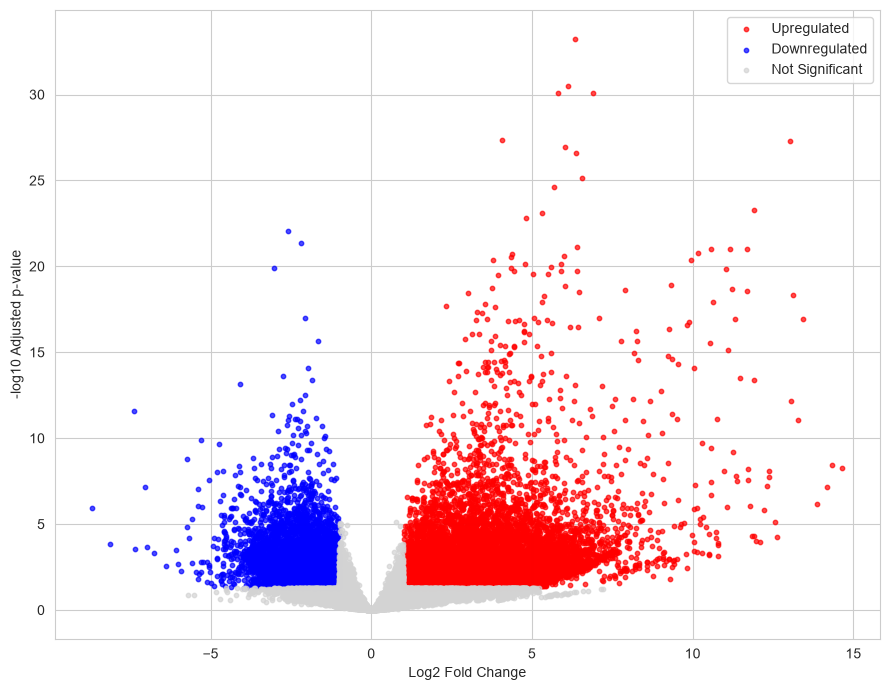

In [46]:
plt.figure(figsize=(9,7))

for group in colors:

    subset = plot_data[
        plot_data["Significant"] == group
    ]

    plt.scatter(
        subset["log2FoldChange"],
        subset["minus_log10_padj"],
        s=10,
        alpha=0.7,
        c=colors[group],
        label=group
    )

plt.xlabel("Log2 Fold Change")

plt.ylabel("-log10 Adjusted p-value")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES/"Volcano_plot.png",
    dpi=300
)

plt.show()

In [52]:
#PCA using normalized counts


normalized = pd.DataFrame(
    dds.layers["normed_counts"],
    index=dds.obs_names,
    columns=dds.var_names
)

In [54]:
#Log transform

log_counts = np.log2(normalized + 1)

In [56]:
normalized.head()

gene_id,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000288661,ENSG00000288662,ENSG00000288663,ENSG00000288665,ENSG00000288667,ENSG00000288669,ENSG00000288670,ENSG00000288671,ENSG00000288674,ENSG00000288675
sample,,,,,,,,,,,,,,,,,,,,,
77c261f0-384c-4906-a57e-7c3b35c17041,1957.823924,7.514036,1538.707673,505.945117,283.863597,707.154313,980.164302,1218.108787,1759.119407,1137.124173,...,0.0,0.000000,31.725931,0.0,0.000000,0.0,268.835524,0.0,0.834893,71.800792
99ff2016-a97a-4142-b70a-1bb59d6264e9,1380.302027,2.671552,1050.810575,666.107042,386.484567,367.783701,1094.445929,970.664006,1492.507223,959.977796,...,0.0,8.014657,10.686209,0.0,5.343105,0.0,326.819899,0.0,6.233622,41.854320
d4649bc7-09d2-4d90-bafd-0bec72429b00,2335.810782,7.961182,606.642064,756.312285,351.884242,567.632273,5591.138078,886.079550,2108.120978,807.263849,...,0.0,7.165064,32.640846,0.0,6.368946,0.0,581.166282,0.0,14.330127,13.534009
afbd1975-263b-404b-a738-886bf25c0223,2653.363843,2.192863,741.187586,764.212644,399.101008,340.990147,467.079751,1816.786731,719.258959,1094.238477,...,0.0,4.385725,31.796509,0.0,13.157176,0.0,131.571761,0.0,4.385725,29.603646
444a2332-9e52-4cf8-94d9-07a8b829633e,1755.220204,5.305070,802.581259,807.128462,593.409940,472.151204,1026.909921,751.804164,1655.939614,1062.529675,...,0.0,16.673076,31.830418,0.0,16.673076,0.0,224.328662,0.0,15.157342,18.946678


In [58]:
#perform PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pcs = pca.fit_transform(log_counts)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1","PC2"],
    index=log_counts.index
)

pca_df = pca_df.join(metadata)

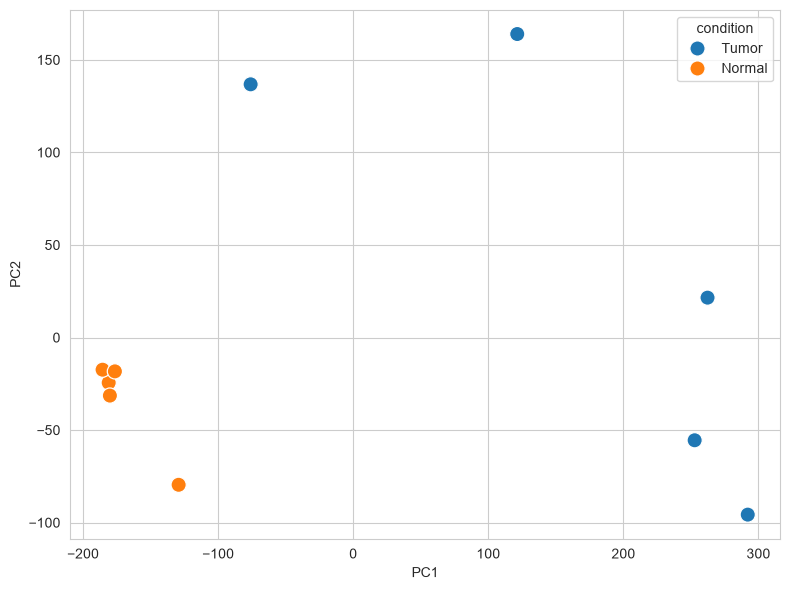

In [60]:
#Plot

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="condition",
    s=120
)

plt.tight_layout()

plt.savefig(
    FIGURES/"PCA_DESeq2.png",
    dpi=300
)

plt.show()

In [62]:
# Save normalized counts to be used for downstream analyses
# (GO, GSEA, enrichment analyses, heatmaps, expression plots)

# Extract normalized counts from PyDESeq2
normalized = pd.DataFrame(
    dds.layers["normed_counts"].T,
    index=dds.var_names,
    columns=dds.obs_names
)

# Set Ensembl ID as a column
normalized.index.name = "ensembl_id"

normalized = normalized.reset_index()

# Remove Ensembl version numbers
# Example: ENSG00000141510.18 -> ENSG00000141510
normalized["ensembl_id"] = (
    normalized["ensembl_id"]
    .astype(str)
    .str.split(".")
    .str[0]
)

# Merge with gene symbols
normalized = normalized.merge(
    gene_annotation,
    left_on="ensembl_id",
    right_index=True,
    how="left"
)

# Use gene symbols as index
normalized = normalized.set_index("gene_symbol")

# Remove unnecessary column
normalized = normalized.drop(
    columns=["ensembl_id"],
    errors="ignore"
)

normalized.head()

,77c261f0-384c-4906-a57e-7c3b35c17041,99ff2016-a97a-4142-b70a-1bb59d6264e9,d4649bc7-09d2-4d90-bafd-0bec72429b00,afbd1975-263b-404b-a738-886bf25c0223,444a2332-9e52-4cf8-94d9-07a8b829633e,64a2ddbe-3614-409a-af16-170a1471db2a,4bed9101-07f4-4d76-b79f-6eb8de04bd19,ddaed459-ab19-4f75-a1a9-72761287c6f5,477a4ae1-84c0-49f2-b3b3-4015b8c26f18,c410d37e-e445-4f5f-8937-e6796dd52364
gene_symbol,,,,,,,,,,
TSPAN6,1957.823924,1380.302027,2335.810782,2653.363843,1755.220204,674.230493,686.452339,550.610758,545.195763,570.150922
TNMD,7.514036,2.671552,7.961182,2.192863,5.305070,4.822822,7.903234,6.090827,0.000000,9.398092
DPM1,1538.707673,1050.810575,606.642064,741.187586,802.581259,936.592001,1113.226985,1130.457485,1049.468842,1121.505659
SCYL3,505.945117,666.107042,756.312285,764.212644,807.128462,584.526007,555.484459,489.702488,702.286068,499.143115
C1orf112,283.863597,386.484567,351.884242,399.101008,593.409940,78.129714,91.451710,74.308089,192.732643,105.467478


In [64]:
#Now Save normalized counts as gene symbols to be used for downstream analyses (enrichment analyses, GO, GSEA,..)


normalized.to_csv(
    DATA/"Normalized_counts.csv"
)

In [66]:
#Top differentially expressed genes



top_genes = results.sort_values("padj").head(100)

top_genes.head()


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Significant
gene_symbol,,,,,,,,
KIF20A,ENSG00000112984,382.973205,6.332758,0.487767,12.983164,1.524506e-38,5.553928e-34,Upregulated
RPS3AP6,ENSG00000234797,892.654768,6.123948,0.492397,12.437020,1.645289e-35,2.996977e-31,Upregulated
TOP2A,ENSG00000131747,2430.671354,6.909832,0.561942,12.296342,9.476981e-35,8.631398e-31,Upregulated
KNL1,ENSG00000137812,467.084898,5.797537,0.470707,12.316653,7.368941e-35,8.631398e-31,Upregulated
NOX4,ENSG00000086991,187.506808,4.062095,0.345472,11.758096,6.416523e-32,4.675207e-28,Upregulated


In [92]:
top_genes.to_csv(
    TABLES/"Top50_DEGs.csv"
)

In [68]:
heatmap_data = normalized.loc[
    top_genes.index
]


In [70]:
heatmap_data.shape

(100, 10)

In [72]:

heatmap_log = np.log2(
    heatmap_data + 1
)

heatmap_z = (
    heatmap_log
    .sub(heatmap_log.mean(axis=1), axis=0)
    .div(heatmap_log.std(axis=1), axis=0)
)

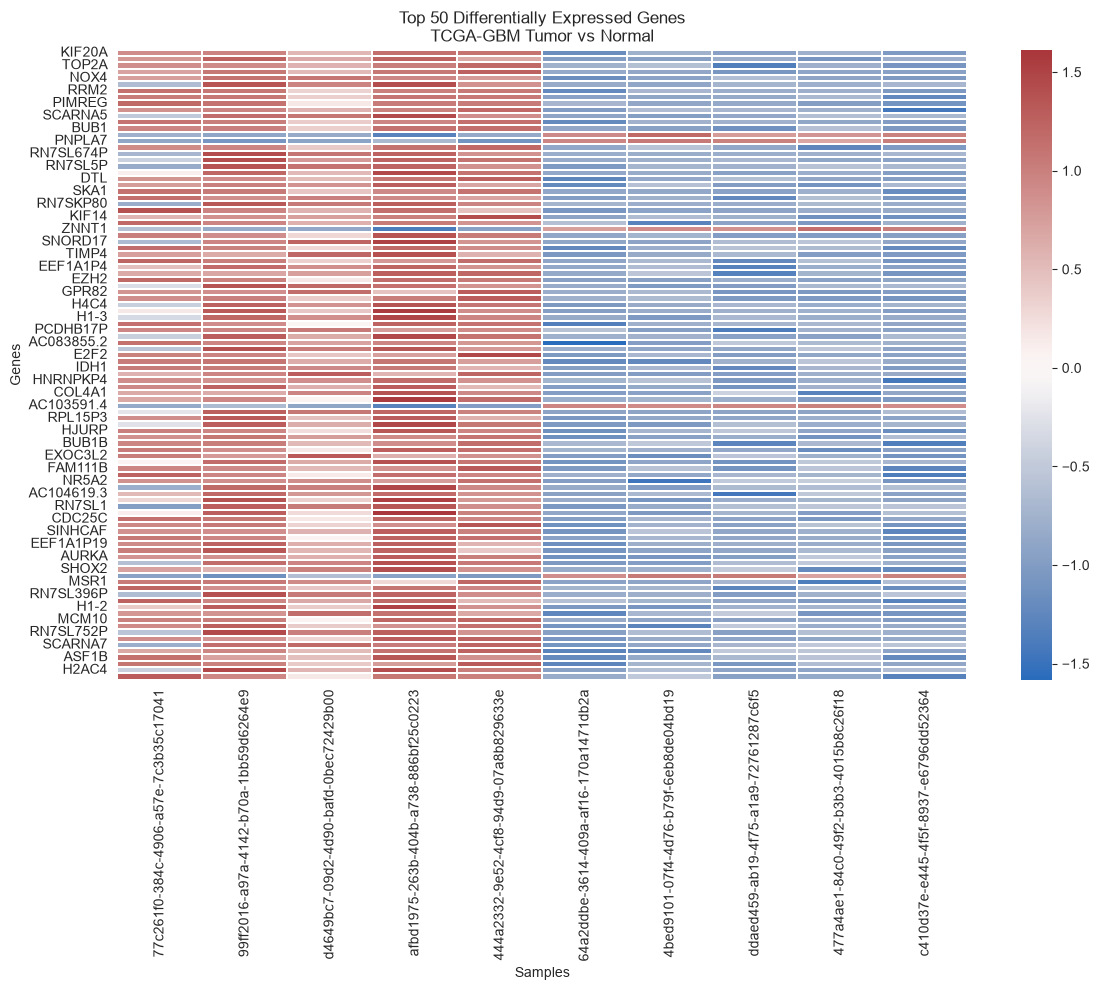

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(12,10))

sns.heatmap(
    heatmap_z,
    cmap="vlag",
    center=0,
    linewidths=0.2
)

plt.xlabel("Samples")
plt.ylabel("Genes")

plt.title(
    "Top 50 Differentially Expressed Genes\nTCGA-GBM Tumor vs Normal"
)

plt.tight_layout()

plt.show()

In [76]:
condition_colors = metadata["condition"].map(
    {
        "Tumor":"red",
        "Normal":"blue"
    }
)

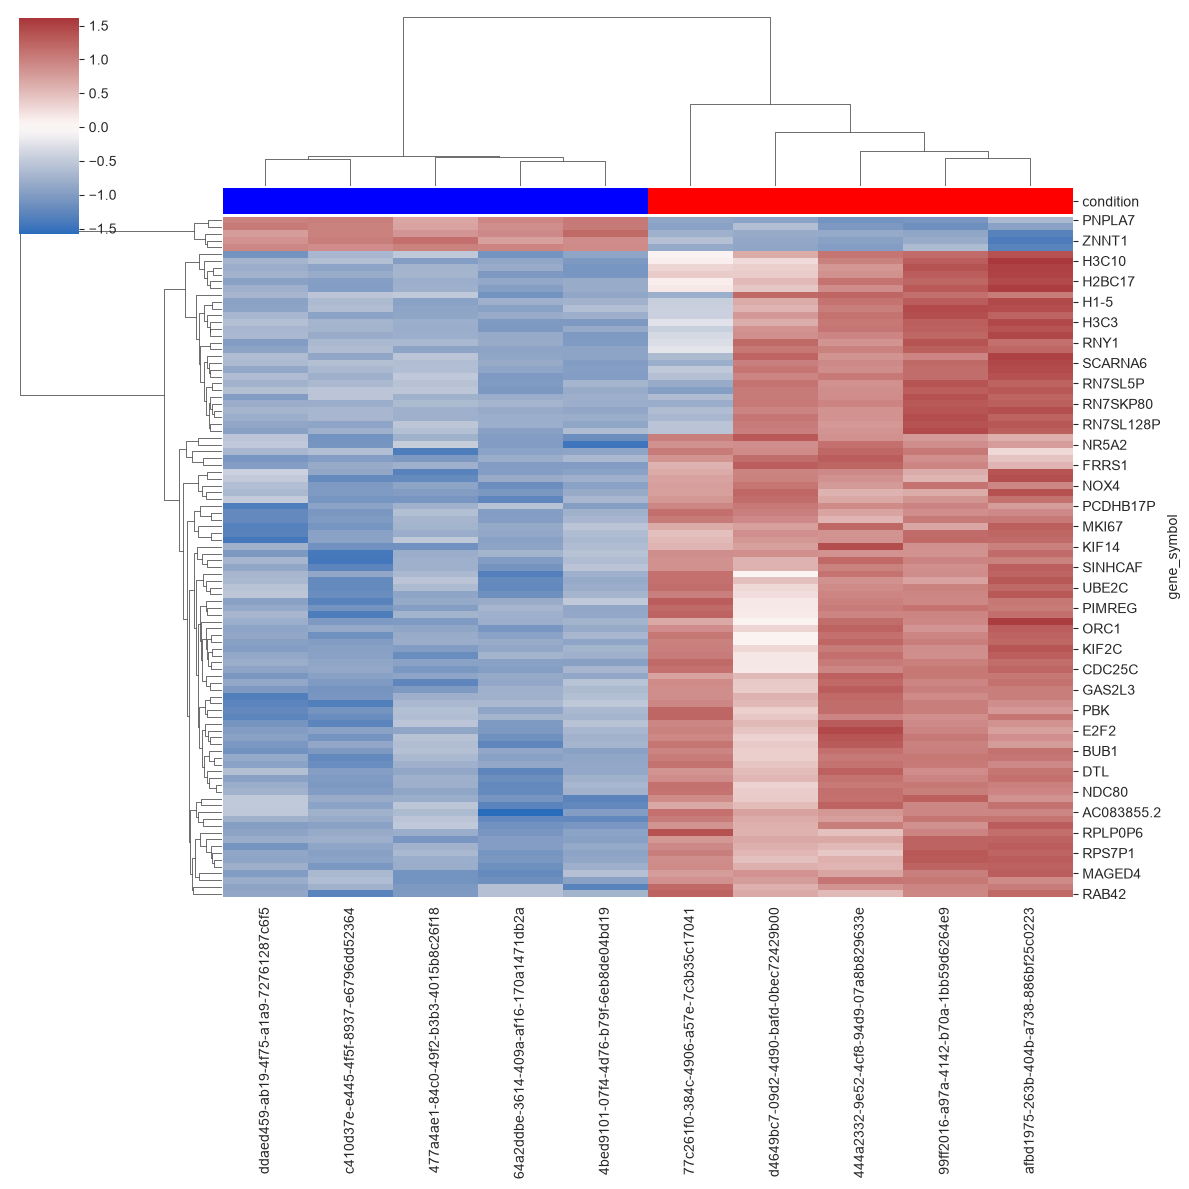

In [78]:
sns.clustermap(
    heatmap_z,
    cmap="vlag",
    center=0,
    col_colors=condition_colors,
    figsize=(12,12)
)

plt.show()

In [80]:
heatmap_data = normalized.loc[top_genes.index]

In [82]:
heatmap_data.shape

(100, 10)

In [84]:
heatmap_log = np.log2(heatmap_data + 1)

heatmap_z = (
    heatmap_log
    .sub(heatmap_log.mean(axis=1), axis=0)
    .div(heatmap_log.std(axis=1), axis=0)
)

#Order samples by condition to prevent mixing up
sample_order = metadata.sort_values("condition").index

heatmap_z = heatmap_z[sample_order]

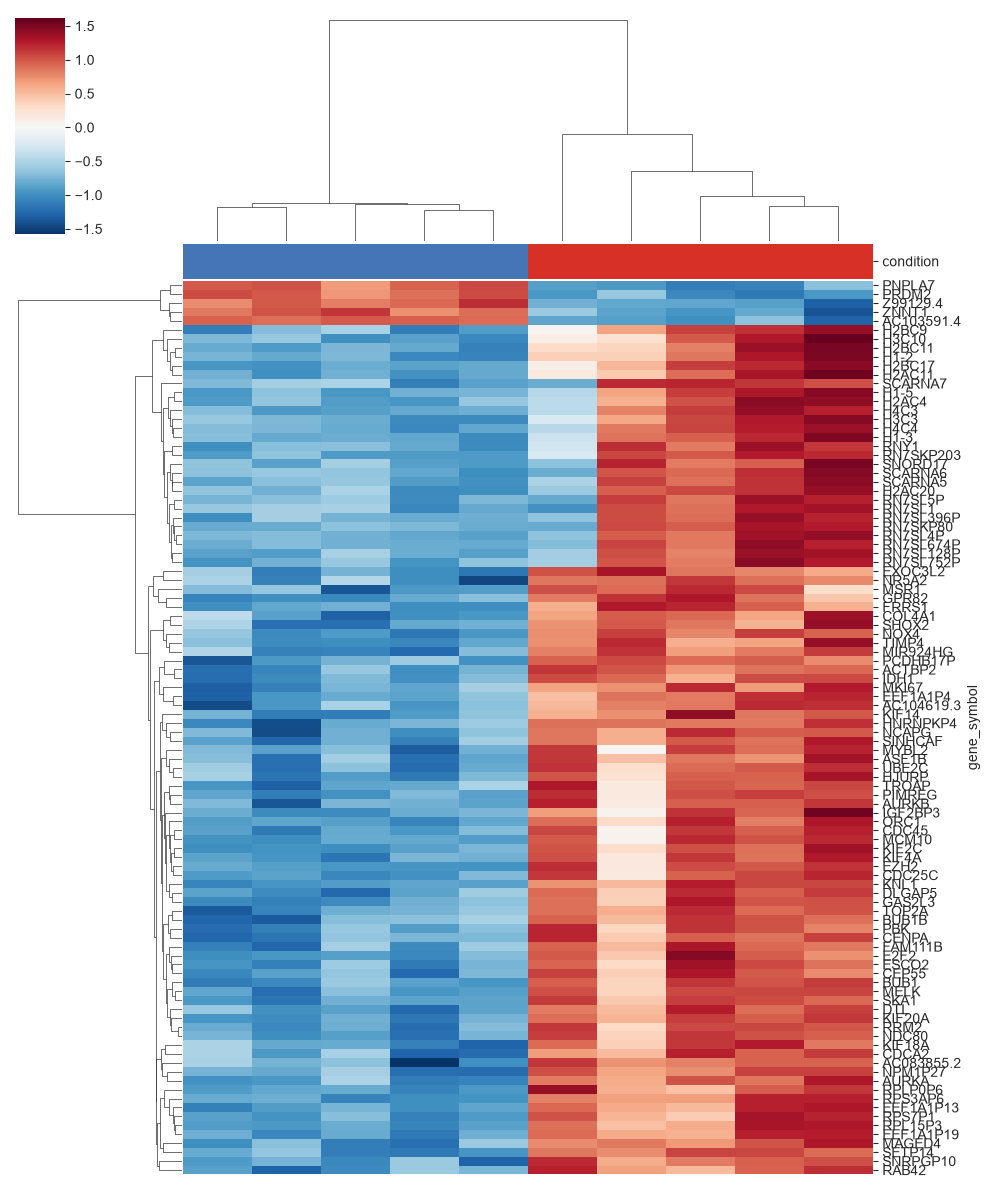

In [86]:


condition_colors = metadata.loc[
    heatmap_z.columns,
    "condition"
].map({
    "Tumor": "#d73027",
    "Normal": "#4575b4"
})

sns.clustermap(
    heatmap_z,
    cmap="RdBu_r",
    center=0,
    col_colors=condition_colors,
    figsize=(10, 12),
    xticklabels=False,
    yticklabels=True
)

plt.show()

In [88]:
#Save normalized counts to be used for downstream analyses (enrichment analyses, GO, GSEA,..)

normalized.to_csv(
    DATA/"Normalized_counts.csv"
)

In [357]:
plt.savefig(
    FIGURES / "Heatmap_Top50_DEGs.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 800x600 with 0 Axes>

In [90]:
genes_of_interest = [
    "EZH2",
    "HIRA",
    "EGFR",
    "PTEN",
    "TP53",
    "TERT"
    
]

normalized.loc[genes_of_interest]

,77c261f0-384c-4906-a57e-7c3b35c17041,99ff2016-a97a-4142-b70a-1bb59d6264e9,d4649bc7-09d2-4d90-bafd-0bec72429b00,afbd1975-263b-404b-a738-886bf25c0223,444a2332-9e52-4cf8-94d9-07a8b829633e,64a2ddbe-3614-409a-af16-170a1471db2a,4bed9101-07f4-4d76-b79f-6eb8de04bd19,ddaed459-ab19-4f75-a1a9-72761287c6f5,477a4ae1-84c0-49f2-b3b3-4015b8c26f18,c410d37e-e445-4f5f-8937-e6796dd52364
gene_symbol,,,,,,,,,,
EZH2,1705.686259,1306.389079,403.631924,1665.479206,1425.548016,80.058843,79.032342,97.453231,80.525282,87.715526
HIRA,364.013318,244.892295,167.980939,430.897517,345.587398,732.104355,742.904012,881.951744,761.689965,850.005220
EGFR,2227.494341,2563.799700,37279.030564,446000.858383,13943.238912,2592.749021,2526.776868,1670.104754,1467.936292,1621.693006
PTEN,2477.962221,3635.982693,3881.076197,2093.087428,3353.561919,6064.216180,6666.942539,5803.339931,2818.384878,5126.137132
TP53,1729.898154,1244.052859,2664.607596,5015.076950,1661.244684,492.892392,438.064980,1179.184100,1011.186331,658.910680
TERT,23.377002,20.481901,20.699073,84.425213,26.525349,2.893693,2.258067,1.218165,0.000000,2.088465


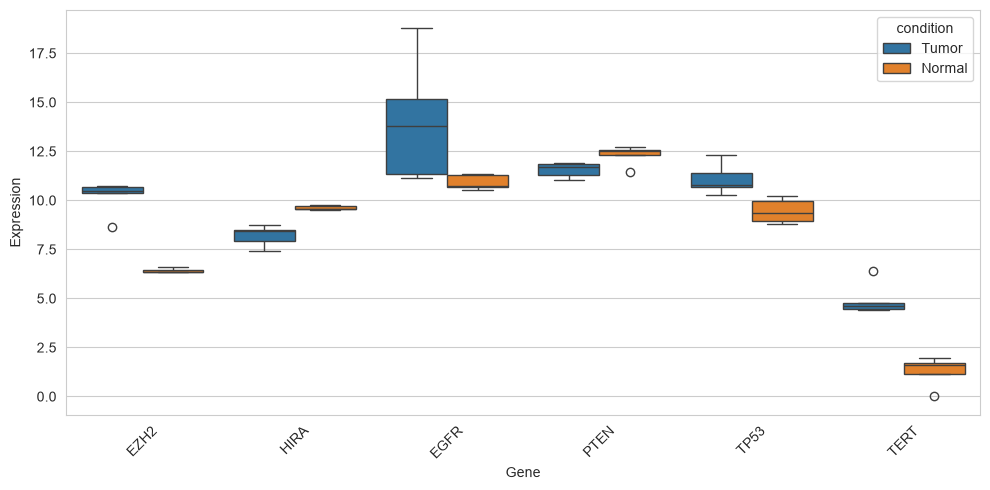

In [92]:



expression = np.log2(normalized.loc[genes_of_interest] + 1)

plot_df = expression.T

plot_df["condition"] = metadata["condition"]

plot_df = plot_df.melt(
    id_vars="condition",
    var_name="Gene",
    value_name="Expression"
)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=plot_df,
    x="Gene",
    y="Expression",
    hue="condition"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [94]:
#another way, Selects genes that are both significant and strongly changed

sig_genes = results[
    (results["padj"] < 0.05) &
    (results["log2FoldChange"].abs() > 1)
]

top_genes = (
    sig_genes
    .sort_values("log2FoldChange", key=abs, ascending=False)
    .head(50)
)

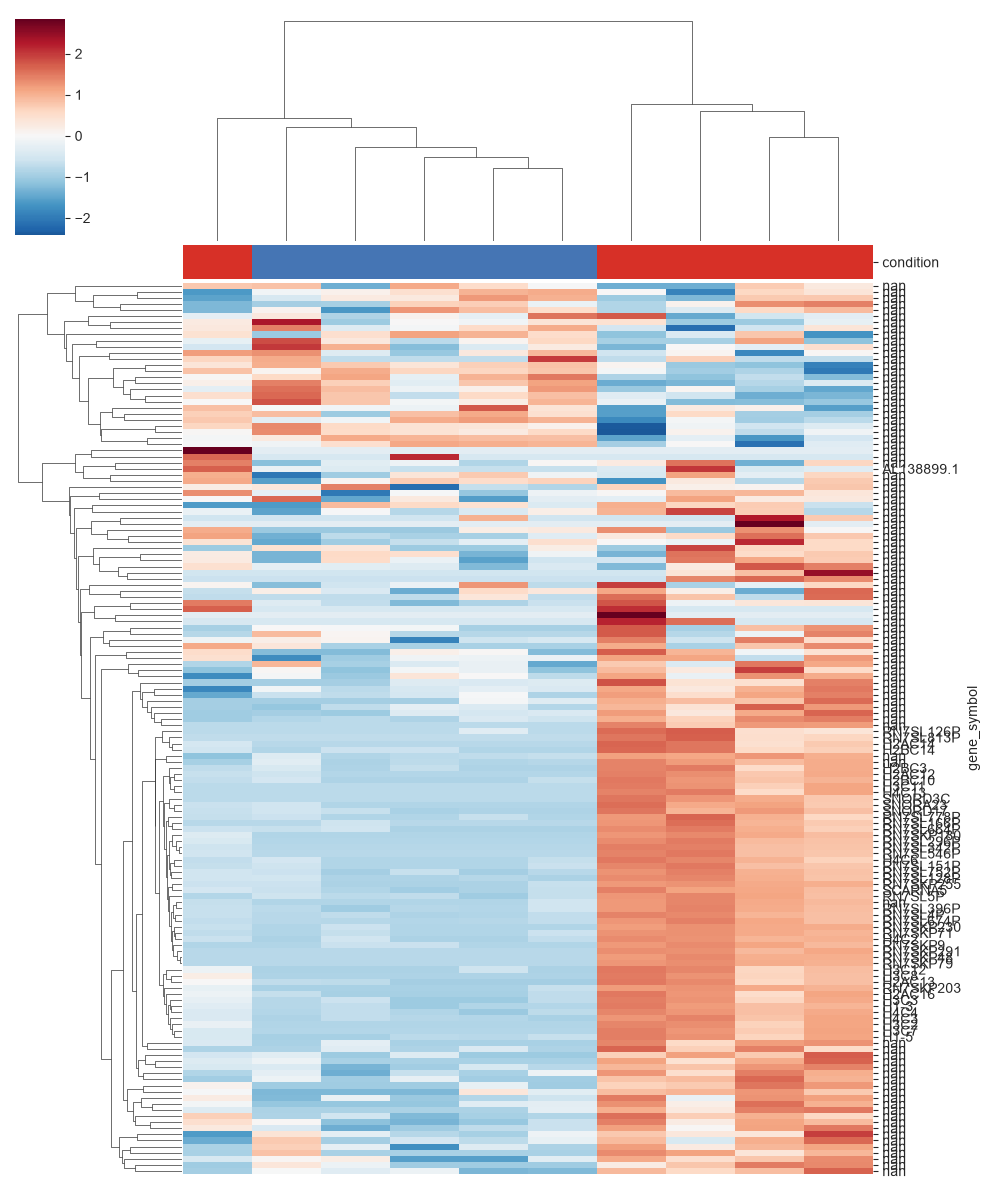

In [96]:
heatmap_data = normalized.loc[top_genes.index]

heatmap_log = np.log2(heatmap_data + 1)


# Remove genes with zero variance
heatmap_log = heatmap_log[
    heatmap_log.std(axis=1) > 0
]
heatmap_z = (
    heatmap_log
    .sub(heatmap_log.mean(axis=1), axis=0)
    .div(heatmap_log.std(axis=1), axis=0)
)

#Order samples by condition to prevent mixing up
sample_order = metadata.sort_values("condition").index

heatmap_z = heatmap_z[sample_order]

condition_colors = metadata.loc[
    heatmap_z.columns,
    "condition"
].map({
    "Tumor": "#d73027",
    "Normal": "#4575b4"
})

sns.clustermap(
    heatmap_z,
    cmap="RdBu_r",
    center=0,
    col_colors=condition_colors,
    figsize=(10, 12),
    xticklabels=False,
    yticklabels=True
)

plt.show()